# Experiment Design Project: Penguins

Dataset: https://allisonhorst.github.io/palmerpenguins/


## Loading the Data and Splitting the Data


In [185]:
library(palmerpenguins)
library(ggplot2)
library(tidyr)
library(dplyr)
library(reshape2)
library(effectsize)
library(permuco)
library(rstatix)
library(emmeans)
library(car)

In [186]:
data(package = 'palmerpenguins')
dim(penguins)

[1] 344   8

Data sets in package 'palmerpenguins':

penguins                Size measurements for adult foraging penguins
                        near Palmer Station, Antarctica
penguins_raw (penguins)
                        Penguin size, clutch, and blood isotope data
                        for foraging adults near Palmer Station,
                        Antarctica

In [187]:
head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


We have 344 entries with 8 Columns in the dataset. It looks like some rows are completely full of NAs and need special treatment.


In [188]:
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NA's   :2         NA's   :2                  

From a first glance on the statistics, it looks like the numerical values are all within a reasonable range without significant outliers. The variable _species_ that will be used as a target later in the project suffers from class imblance. The data contains NA-values but very little compared to the whole dataset.


In [189]:
penguins_no_na <- na.omit(penguins)
dim(penguins_no_na)

[1] 333   8

Removing the NAs only reduced the data by 11 Rows, which is acceptable due to the fact that it is <1% of the full dataset. Since we want to do analysis on variables that had NAs (e.g. Anova based on gender) they were of no value for the use-case. The next step will be to split the data and perform further analysis on the Train-Set to gain insights into the domain.


In [190]:
set.seed(42)

n <- nrow(penguins_no_na)
idx <- sample(n) # shuffle data

train_indices <- idx[1:floor(0.7 * n)] # first 70%, train-set
val_indices <- idx[(floor(0.7 * n) + 1):floor(0.85 * n)] # 15% validation-set
test_indices <- idx[(floor(0.85 * n) + 1):n] # 15% test-set

train_set <- penguins_no_na[train_indices, ]
validation_set <- penguins_no_na[val_indices, ]
test_set <- penguins_no_na[test_indices, ]

print(dim(train_set))
print(dim(validation_set))
print(dim(test_set))

[1] 233   8
[1] 50  8
[1] 50  8


## Exploratory Data Analysis


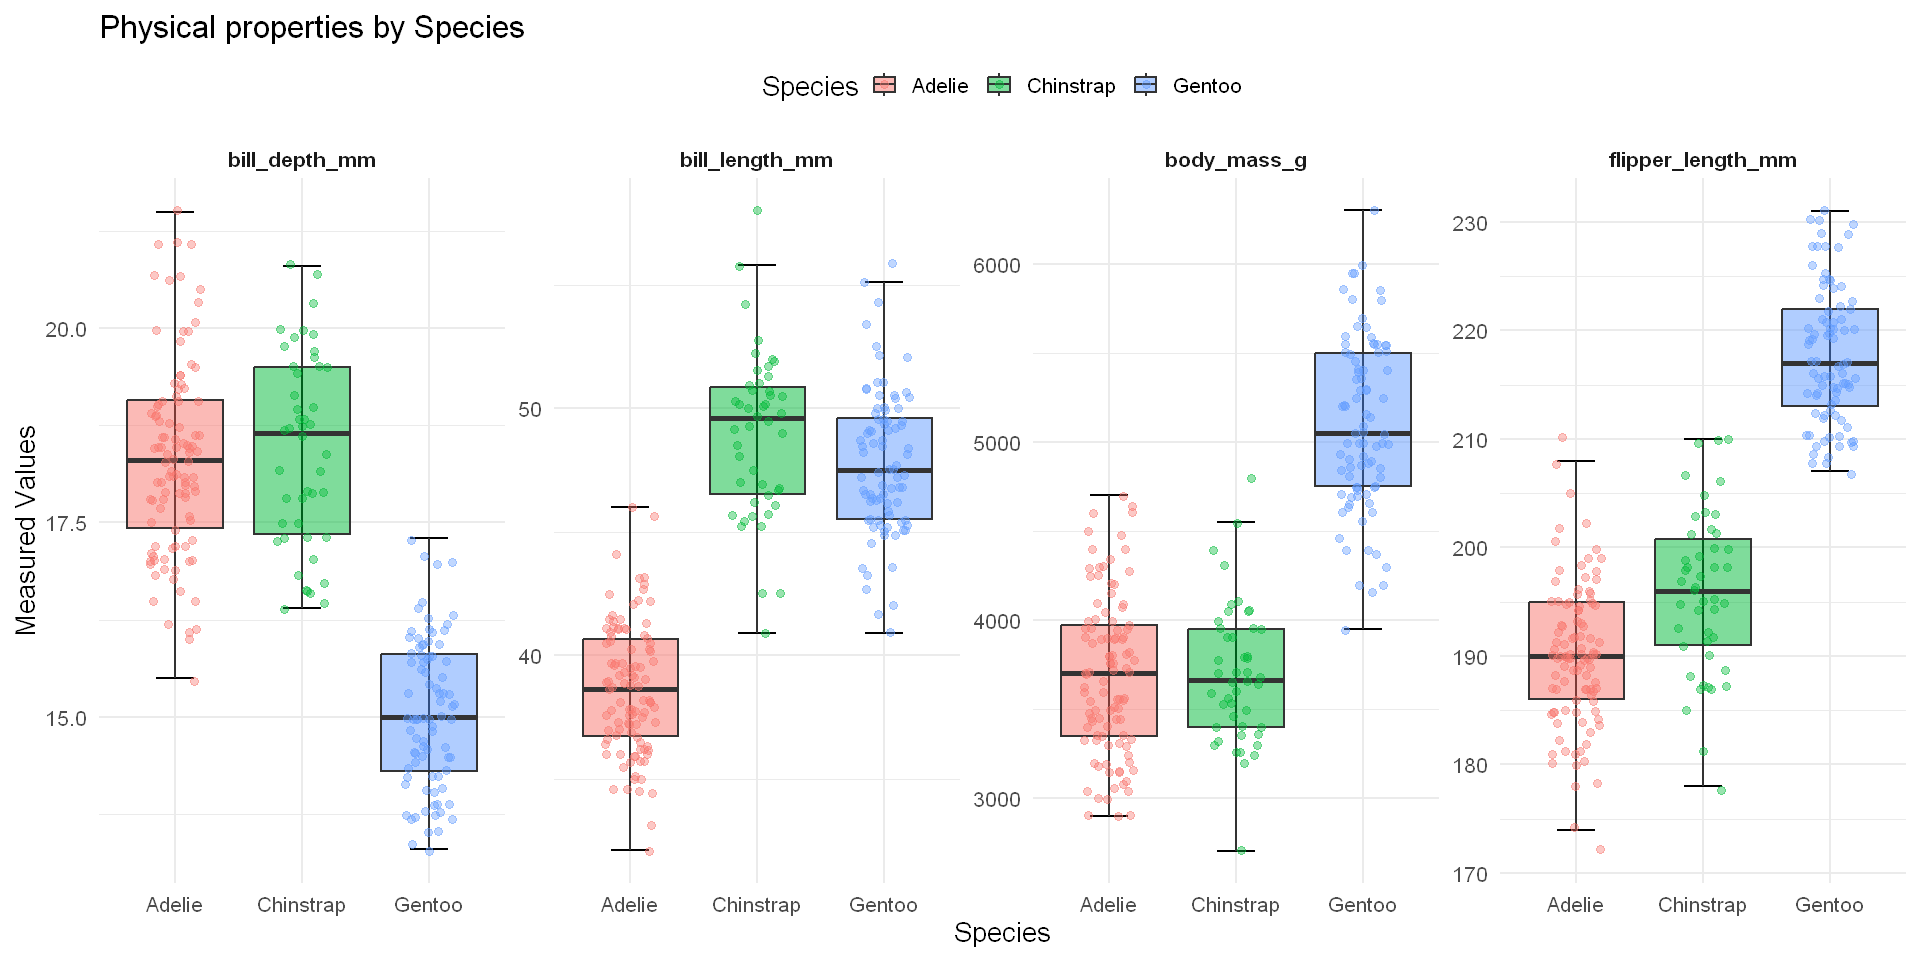

In [191]:
options(repr.plot.width = 16, repr.plot.height = 8) # settings for the notebooks

train_set |>
  pivot_longer(cols = c(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g),
               names_to = "variable", 
               values_to = "value") |>
  ggplot(aes(x = species, y = value, fill = species)) +
  stat_boxplot(geom = "errorbar", width = 0.3) + 
  geom_boxplot(outlier.shape = NA, alpha = 0.5) +
  geom_jitter(aes(color = species), width = 0.2, alpha = 0.4) + # data points, jitter moves sideways
  facet_wrap(~variable, ncol = 4, scales = "free_y") + # scale plots accordingly to each variable
  theme_minimal(base_size = 16) +
  labs(title = "Physical properties by Species",
       x = "Species",
       y = "Measured Values",
       fill = "Species",
       color = "Species") +
  theme(legend.position = "top", ,strip.text = element_text(face = "bold"))

From the plot we can see that there are very little outliers in the data. Also the plot shows that _Gentoo_ penguins tend to be distinguishable to the others by their _bill depth_, _body mass_ and _flipper length_. On the other hand _Adelie_ and _Chinstrp_ penguins have very similar boxplots overall while the Adelie species tends to have smaller _bill lenght_ compared to the other species.


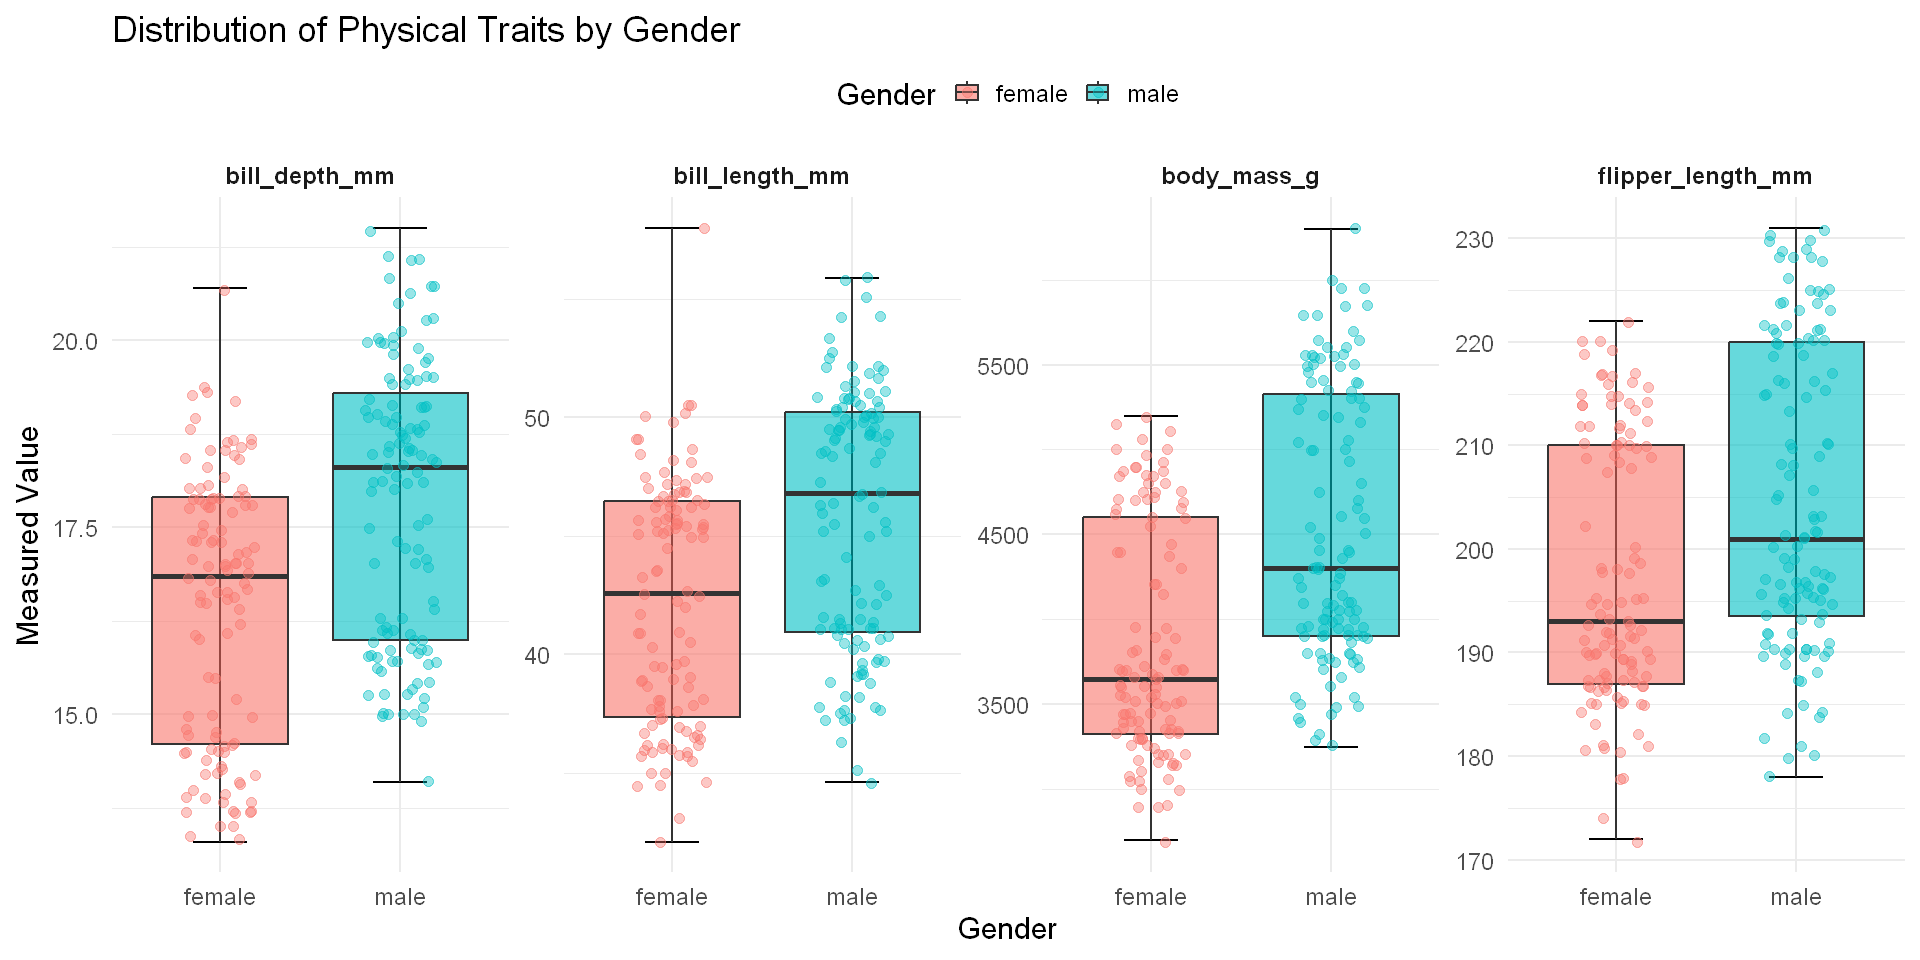

In [192]:
penguins_gender <- train_set |>
  filter(!is.na(sex)) %>%
  pivot_longer(cols = c(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g),
               names_to = "variable", 
               values_to = "value")

# 3. Create the plot
ggplot(penguins_gender, aes(x = sex, y = value, fill = sex)) +
  stat_boxplot(geom = "errorbar", width = 0.3) + 
  geom_boxplot(outlier.shape = NA, alpha = 0.6) +
  geom_jitter(aes(color = sex), width = 0.2, alpha = 0.4) + 
  facet_wrap(~variable, ncol = 4, scales = "free_y") + 
  theme_minimal(base_size = 18) +
  labs(title = "Distribution of Physical Traits by Gender",
       x = "Gender",
       y = "Measured Value",
       fill = "Gender",
       color = "Gender") +
  theme(legend.position = "top",strip.text = element_text(face = "bold")) # bold headers for features

The plot above shows how the numerical features differ between male and female penguins. It seems that male penguins tend to have larger bill sizes, are heavier and have longer flippers, which concides with the fact that in animal world male animails are generally larger and heavier than females.


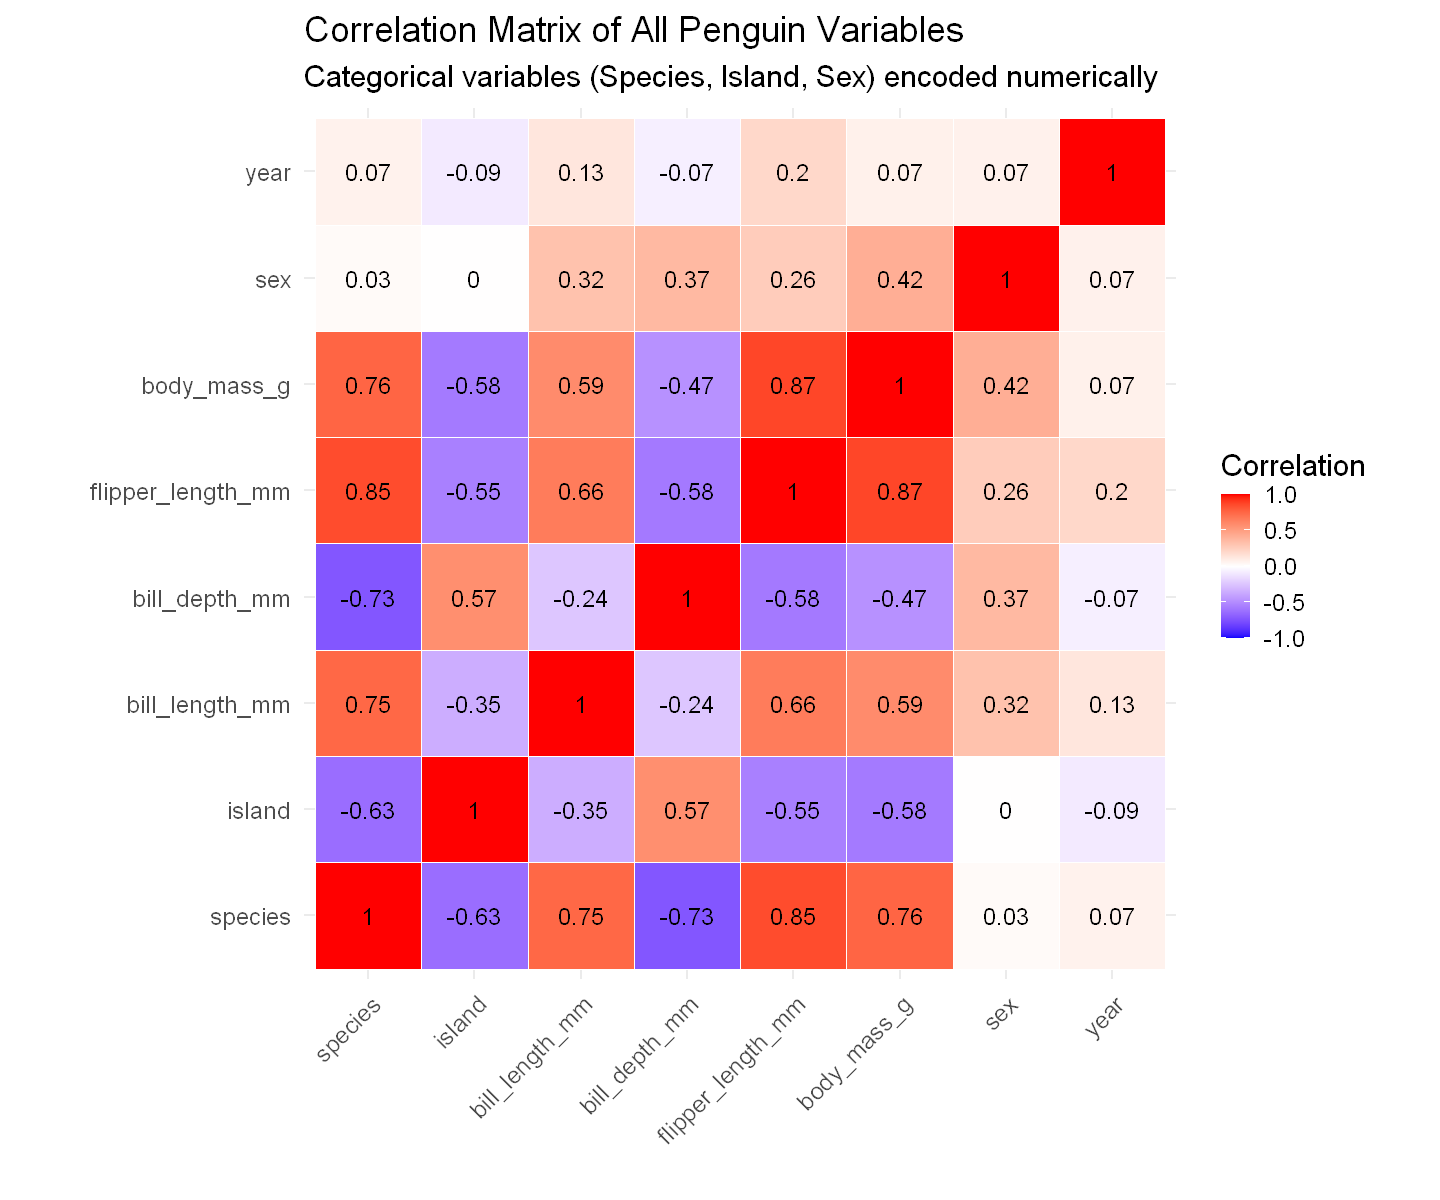

In [193]:
options(repr.plot.width = 12, repr.plot.height = 10)

# convert factors to numerics for  correlation calculation
cor_data <- train_set %>%
  mutate(across(where(is.factor), as.numeric)) |>
  cor(use = "complete.obs")

# melt transforms from wide format into long format, for easier plotting
melted_cor <- melt(cor_data)

ggplot(melted_cor, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-1,1), space = "Lab", 
                       name="Correlation") +
  theme_minimal(base_size = 18) + 
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  coord_fixed() +
  labs(title = "Correlation Matrix of All Penguin Variables",
       subtitle = "Categorical variables (Species, Island, Sex) encoded numerically",
       x = "", y = "") + # x and y need to be specifically set to ""
  geom_text(aes(label = round(value, 2)), color = "black", size = 5)

- year has no correlation => confounding variable => remove
- sex has moderate positive correlation with size, and mass => expected from previous plot
- body mass has strong pos correlation with species (maybe because some species tend to be heavier), bill_length and fillper length
- island has correlation with species and other measurements => maybe some species are more common on some islands => probably confounding variable => remove, also with regards to generalization

Conclusions

- Classification: Remove year, island (we want the model to generalize to other islands) and sex
- Regression: Remove year and island
- Other variables seem to be decent predictors to overall strong correlation.


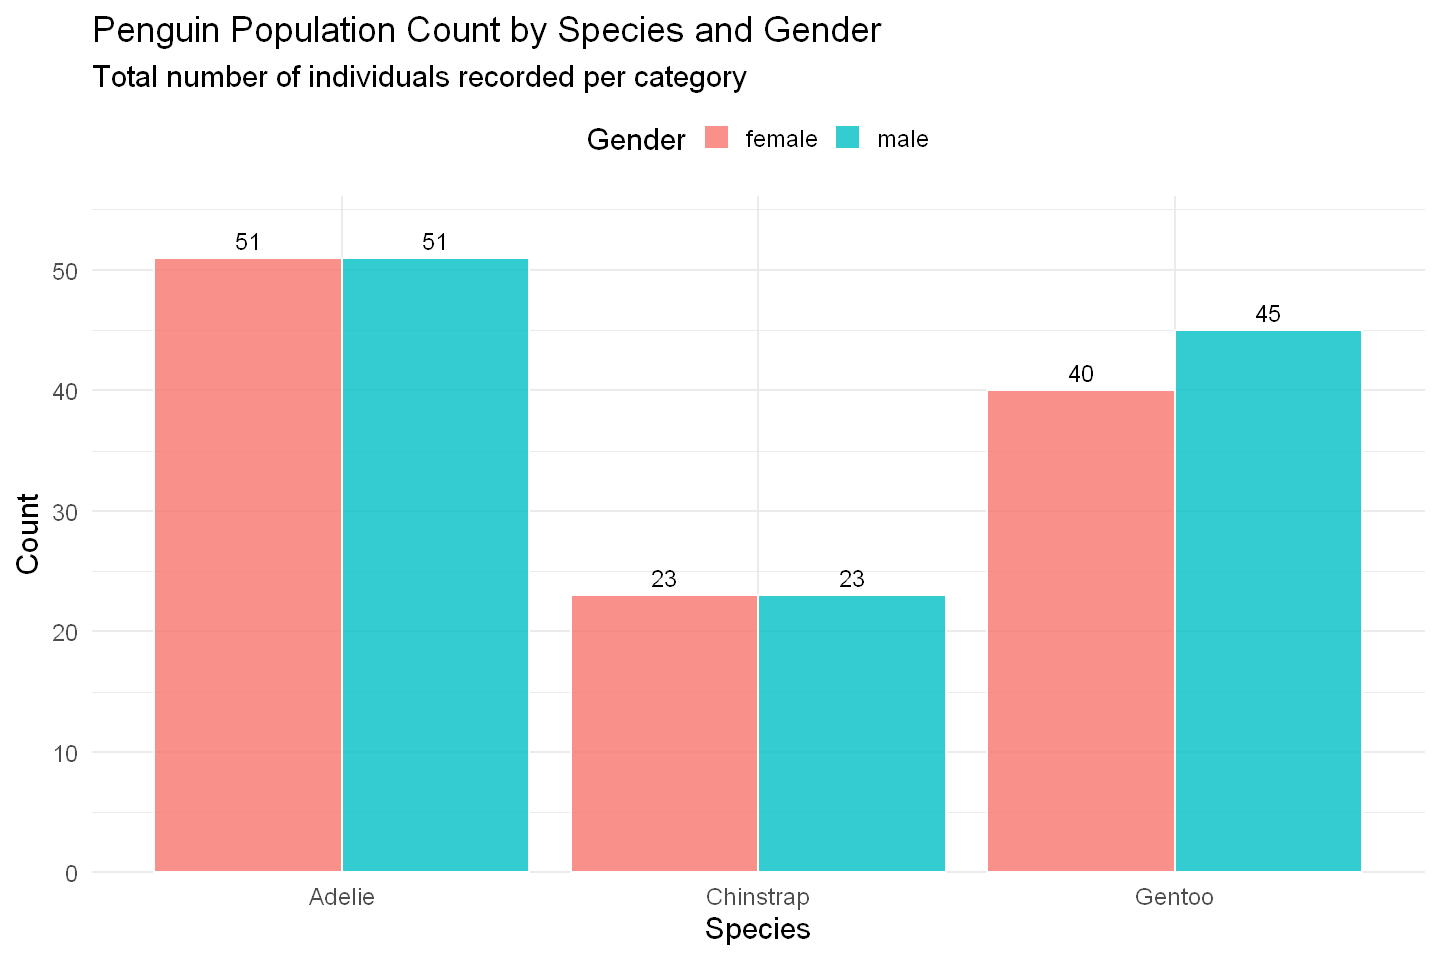

In [194]:
options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(train_set, aes(x = species, fill = sex)) +
  geom_bar(position = "dodge", color = "white", alpha = 0.8) +
  geom_text(stat = 'count', 
            aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5, 
            size = 5) +
  theme_minimal(base_size = 18) +
  labs(title = "Penguin Population Count by Species and Gender",
       subtitle = "Total number of individuals recorded per category",
       x = "Species",
       y = "Count",
       fill = "Gender") +
  theme(legend.position = "top") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) # adding space for labels above bars

The plot shows the number of samples in the train set for each species, by gender. What stings out the most is that there is a significant imbalance between _Chinstrap_ and other penguins, which needs special care when performing classification (e.g. weigh classes). The difference between male and female penguins within each class is well balanced.


Warning message in ks.test.default(x = test_set$body_mass_g, y = "pnorm", mean = mean(test_set$body_mass_g), :
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  test_set$body_mass_g
D = 0.14365, p-value = 0.2535
alternative hypothesis: two-sided


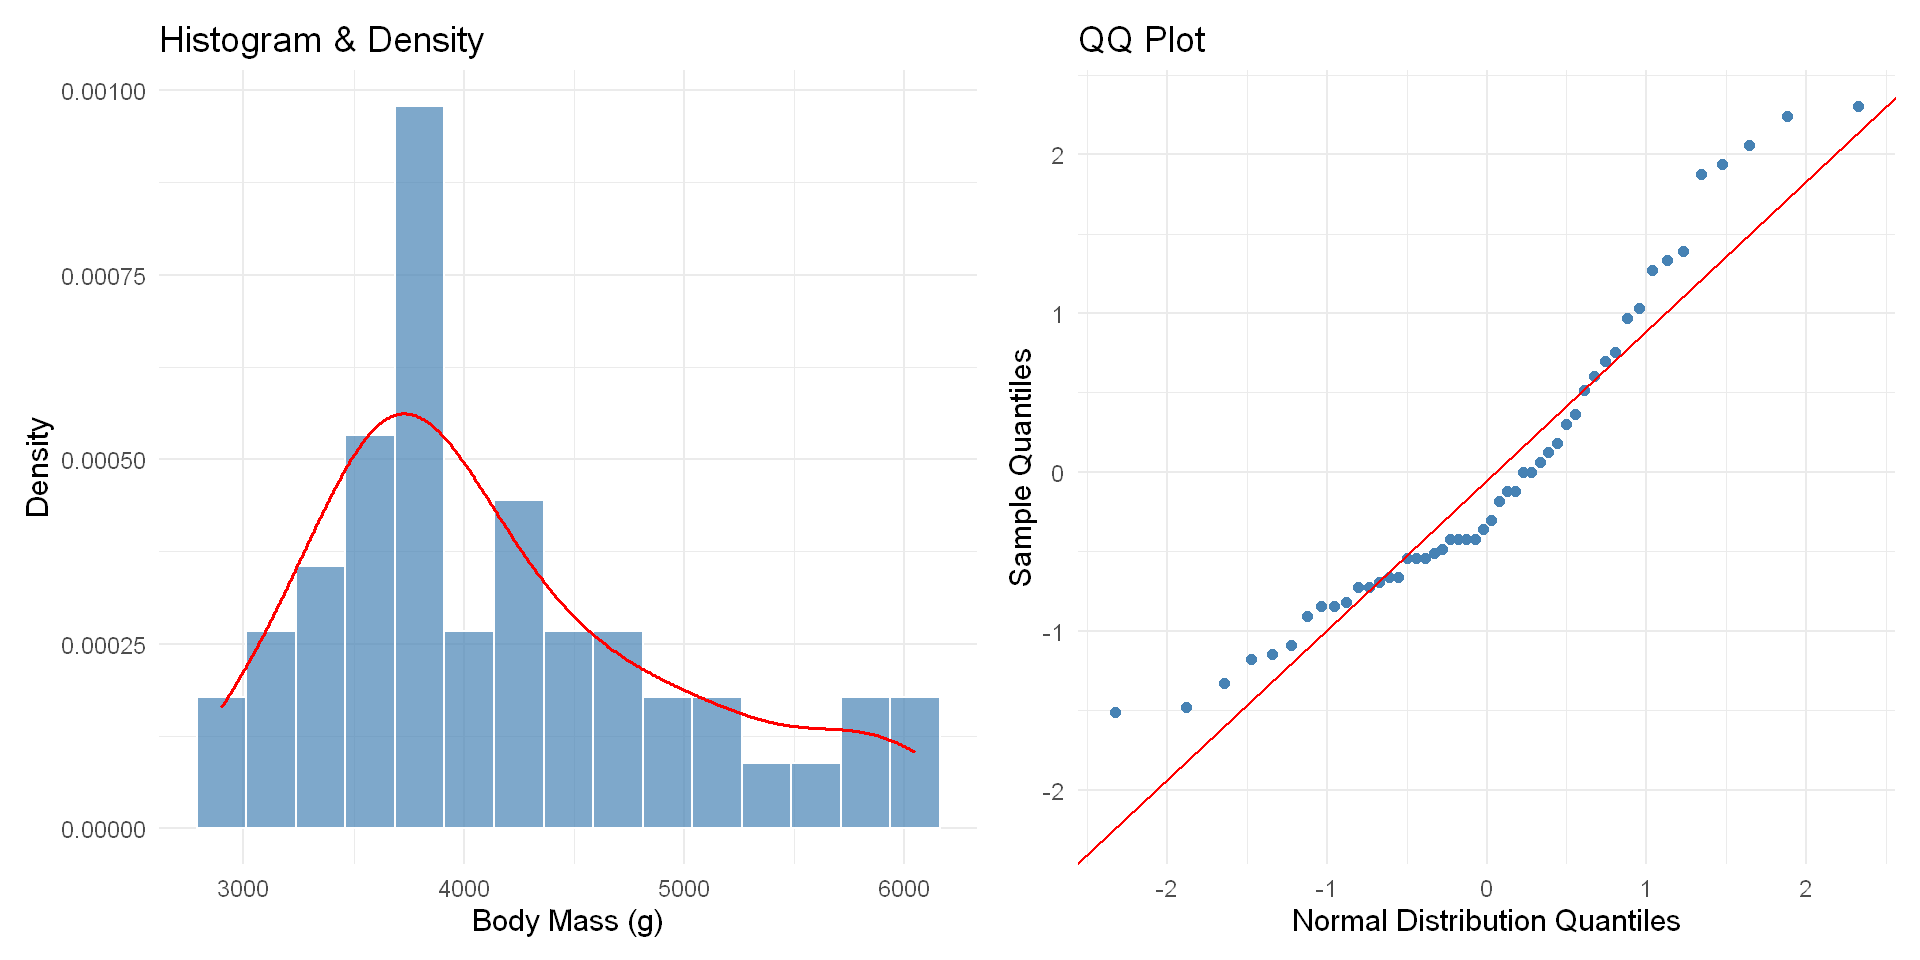

In [195]:
# 1. Set plot size for the Notebook
options(repr.plot.width = 16, repr.plot.height = 8)

# Histogram
p_hist <- ggplot(test_set, aes(x = body_mass_g)) +
  geom_histogram(aes(y = after_stat(density)), bins = 15, 
                 fill = "steelblue", color = "white", alpha = 0.7) +
  geom_density(color = "red", linewidth = 1) +
  theme_minimal(base_size = 18) +
  labs(title = "Histogram & Density",
       x = "Body Mass (g)",
       y = "Density")

# 3. Q-Q Plot
p_qq <- ggplot(test_set, aes(sample = scale(body_mass_g))) + #scale() to get actual same x and y
  stat_qq(color = "steelblue") +
  stat_qq_line(color = "red") +
  theme_minimal(base_size = 18) +
  labs(title = "QQ Plot",
       x = "Normal Distribution Quantiles",
       y = "Sample Quantiles")

# plot nex to eachother
p_hist + p_qq

ks.test(
    x = test_set$body_mass_g,
    y = "pnorm", # Test against normal distribution
    mean = mean(test_set$body_mass_g),
    sd = sd(test_set$body_mass_g),
    alternative = "two.sided" # Standard value
)

The result of the KS-Test (>0.05) indicates that there is not enough evidence to reject the Null-Hypothesis (body_mass follows a normal distribution). When looking at the histogram it turns out that the variable does not look normally distributed at all, with two "humps" instead of the classical bell-shape. Considering the fact that we look at the whole distribution of penguins and we know from previous results that the animails differ in body_mass based on their species it makes more sense to look at the distribution for each species.


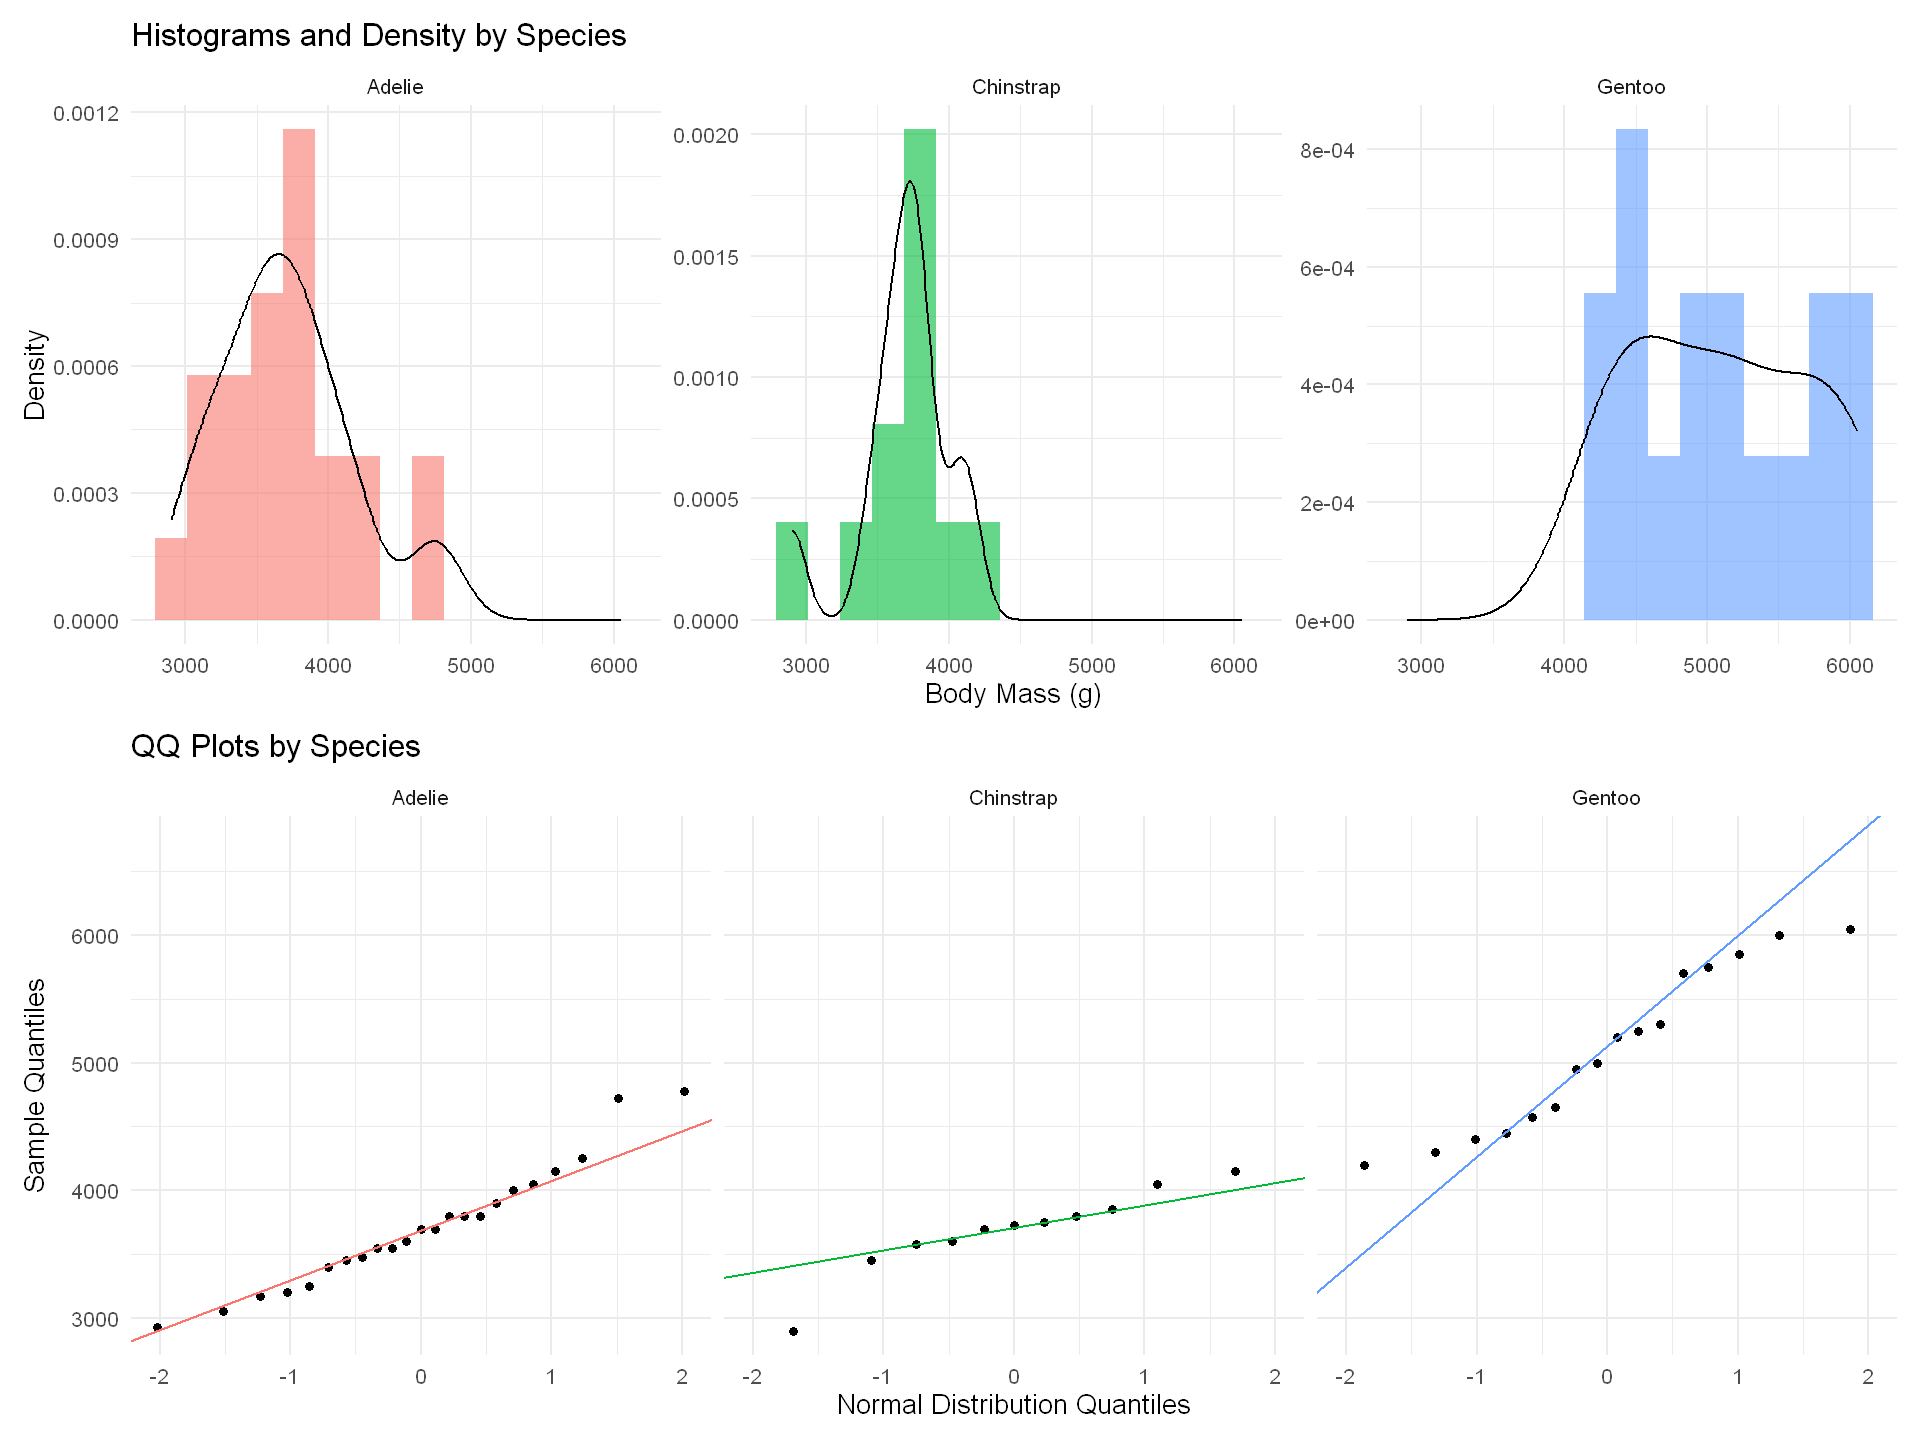

In [196]:
options(repr.plot.width = 16, repr.plot.height = 12)

p_hist_species <- ggplot(test_set, aes(x = body_mass_g, fill = species)) + # fill is like hue in seaborn
  geom_histogram(aes(y = after_stat(density)), bins = 15, alpha = 0.6) +
  geom_density(, linewidth = 0.8, alpha=0) +
  facet_wrap(~species, scales = "free_y") +
  theme_minimal(base_size = 16) +
  theme(legend.position = "none") +
  labs(title = "Histograms and Density by Species",
       x = "Body Mass (g)",
       y = "Density")

p_qq_species <- ggplot(test_set, aes(sample = (body_mass_g), color = species)) +
  stat_qq(color="black") +
  stat_qq_line() +
  facet_wrap(~species) +
  theme_minimal(base_size = 16) +
  theme(legend.position = "none") +
  labs(title = "QQ Plots by Species",
       x = "Normal Distribution Quantiles",
       y = "Sample Quantiles")

p_hist_species / p_qq_species

After splitting the data by penguins species it turns out that the two first histograms look more like the classical normal distribution but still with small humps in the plot. The weight for _Gentoo_ penguins even looks like it has two different groups within that species. Since we know that also gender can influcence the body mass we could generate even more insights by splitting the data by gender and species. The qq-plots on the other hand look like the data is normally distributed in the middle but slightly S-shaped towards the upper and lower end but not in a way that a normal distribution could be impossible.


Warning message:
"There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `ks_p = ks.test(body_mass_g, "pnorm", mean = mean(body_mass_g),
  sd = sd(body_mass_g))$p.value`.
ℹ In group 1: `species = Adelie` `sex = female`.
Caused by warning in `ks.test.default()`:
! ties should not be present for the one-sample Kolmogorov-Smirnov test
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings."


# A tibble: 6 × 8
  species   sex        n  ks_p shapiro_p ks_normal shapiro_normal match
  <fct>     <fct>  <int> <dbl>     <dbl> <lgl>     <lgl>          <lgl>
1 Adelie    female    51 0.823     0.302 TRUE      TRUE           TRUE 
2 Adelie    male      51 0.765     0.630 TRUE      TRUE           TRUE 
3 Chinstrap female    23 0.940     0.167 TRUE      TRUE           TRUE 
4 Chinstrap male      23 0.799     0.803 TRUE      TRUE           TRUE 
5 Gentoo    female    40 0.551     0.216 TRUE      TRUE           TRUE 
6 Gentoo    male      45 0.827     0.891 TRUE      TRUE           TRUE 


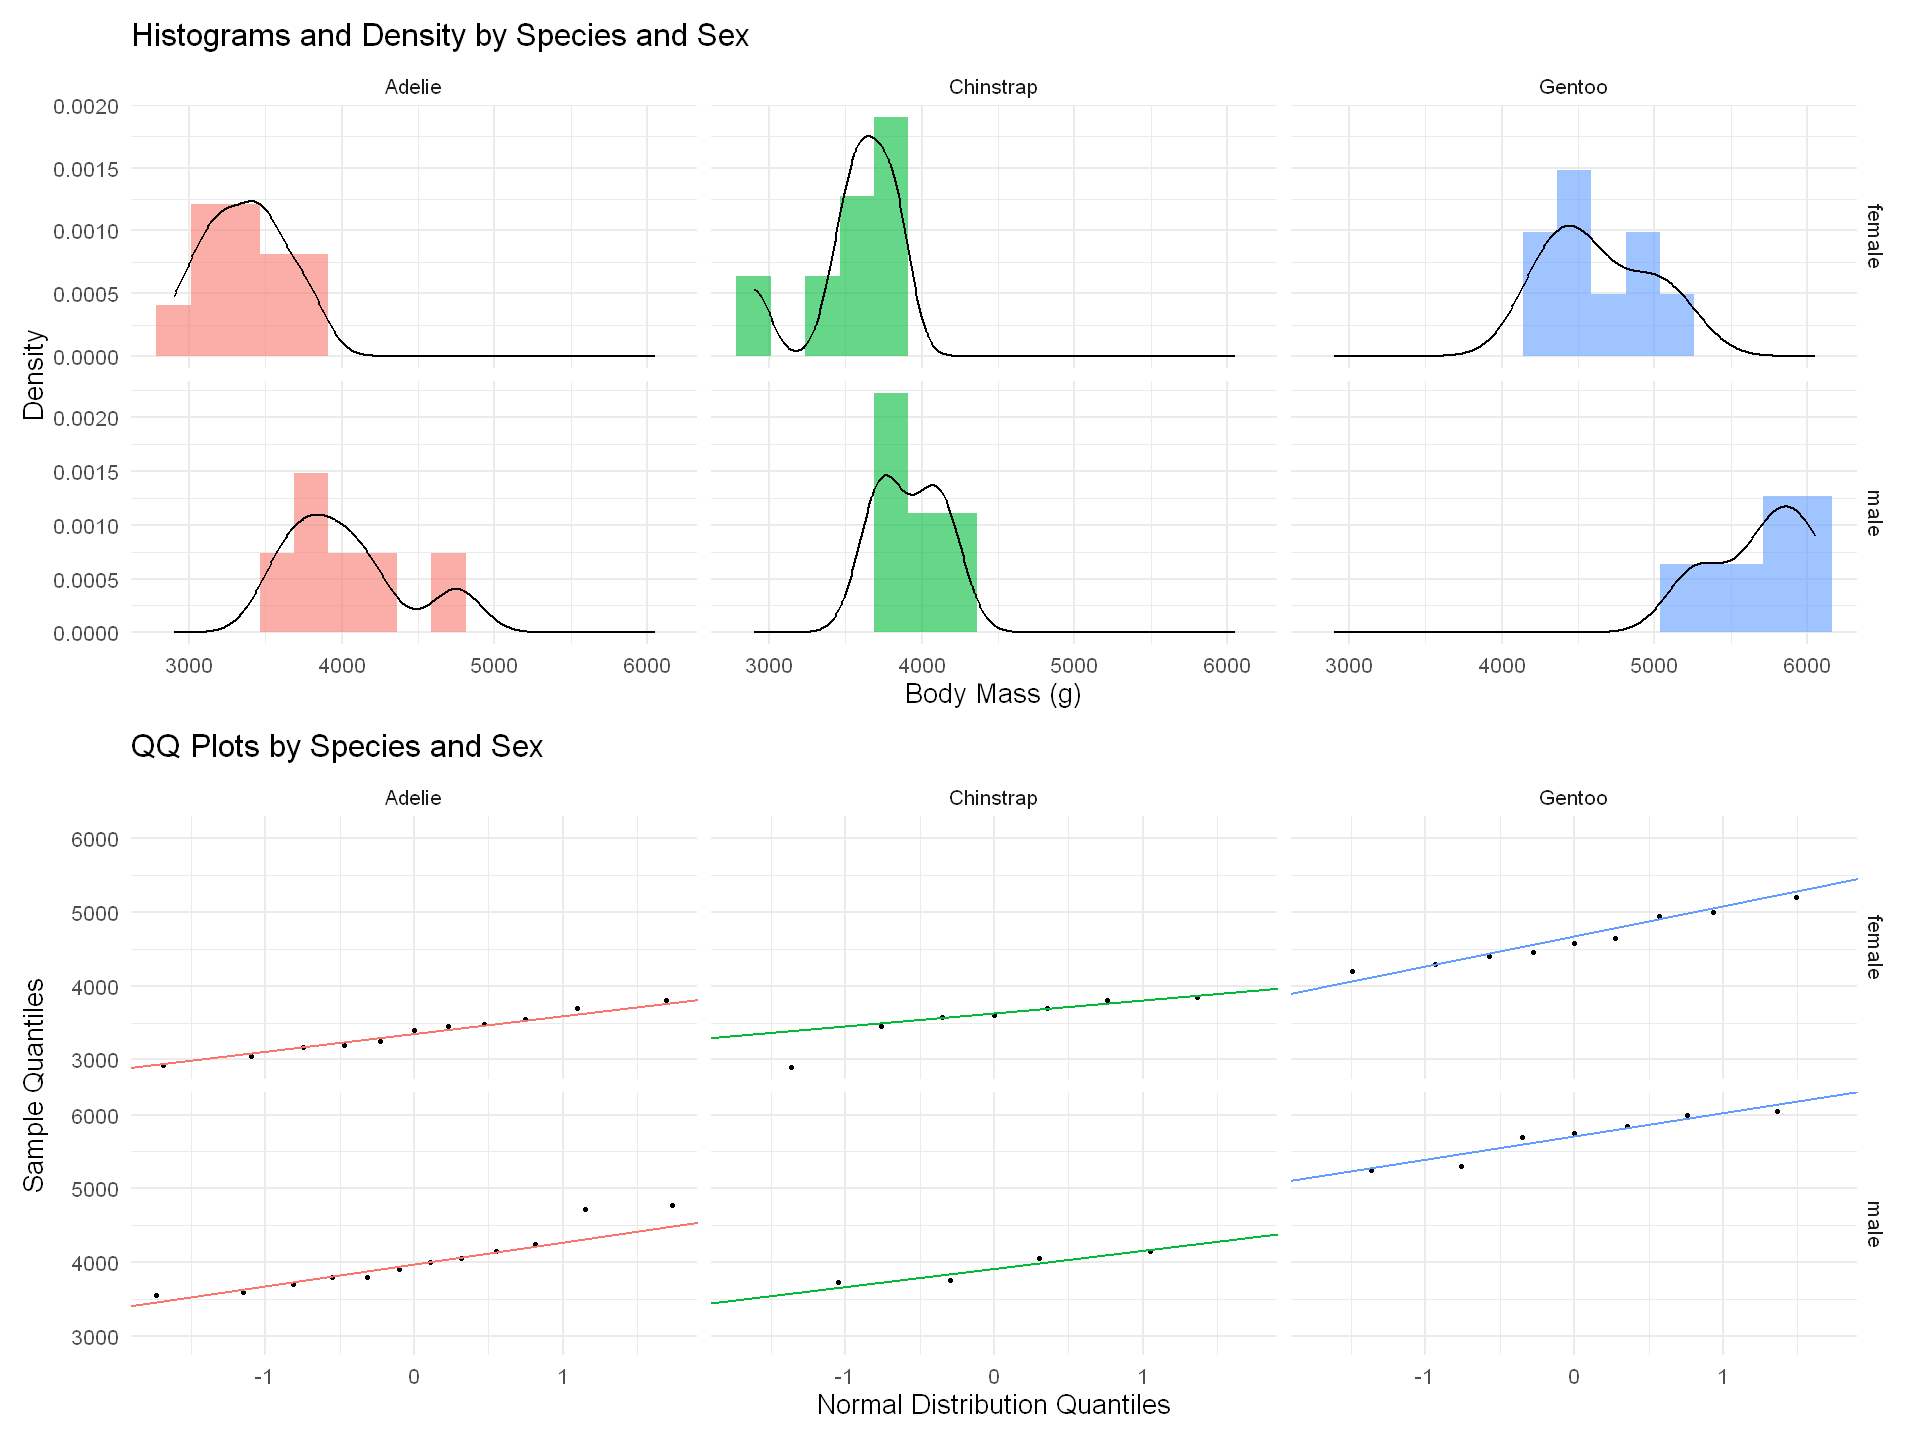

In [197]:
options(repr.plot.width = 16, repr.plot.height = 12)

# histograms
p_hist_sex <- ggplot(test_set, aes(x = body_mass_g, fill = species)) +
  geom_histogram(aes(y = after_stat(density)), bins = 15, alpha = 0.6) +
  geom_density(linewidth = 0.8, alpha=0) +
  # Split by sex and species
  facet_grid(sex ~ species, scales = "free_y") + 
  theme_minimal(base_size = 16) +
  theme(legend.position = "none") +
  labs(title = "Histograms and Density by Species and Sex",
       x = "Body Mass (g)",
       y = "Density")

# qq-plots
p_qq_sex <- ggplot(test_set, aes(sample = body_mass_g, color = species)) +
  stat_qq(color = "black", size = 1) +
  stat_qq_line() +
  facet_grid(sex ~ species) +
  theme_minimal(base_size = 16) +
  theme(legend.position = "none") +
  labs(title = "QQ Plots by Species and Sex",
       x = "Normal Distribution Quantiles",
       y = "Sample Quantiles")

p_hist_sex / p_qq_sex

normality_comparison <- train_set |>
  filter(!is.na(sex), !is.na(body_mass_g)) |>
  group_by(species, sex) |>
  summarise(
    n = n(),
    # Kolmogorov-Smirnov p-value
    ks_p = ks.test(body_mass_g, "pnorm", 
                   mean = mean(body_mass_g), 
                   sd = sd(body_mass_g))$p.value,
    # Shapiro-Wilk p-value
    shapiro_p = shapiro.test(body_mass_g)$p.value,
    .groups = 'drop'
  ) |>
  mutate(
    ks_normal = ks_p > 0.05,
    shapiro_normal = shapiro_p > 0.05,
    match = (ks_normal == shapiro_normal)
  )

print(normality_comparison)

After dividing the data by species and sex, the histograms for each subgroup align much more closely with a normal distribution, despite some minor peaks and slight skewness. This is further supported by the QQ-plots, which show a relatively strong linear trend across all subgroups.To quantify these observations, normality tests were performed for each combination of factors. While the KS-test was included, the Shapiro-Wilk test was prioritized as it is better suited for the small sample sizes in this dataset. For every subgroup, both tests yielded p-values significantly greater than $0.05$, indicating no statistical evidence to reject the assumption of normality within each subgroup.


## ANOVA: Species, mass and gender


Anova setup
Theory: body_mass_g differs depending on species and sex of penguins
Independent variables (factors): species (3 levels), sex (2 levels)
Dependent variable: body_mass_g

Assumptions:

- Normality within each group
- Homogenity of variances, levene test
- Independence, measurements of one group have no influence on other groups
- Measurement level, the dependent varibale should have a metric scale level

Hypothesies:
**H0_a**: Species has no effect on body_mass_g
**H1_a**: Species has an effect on body_mass_g

**H0_b**: Sex has no effect on body_mass_g
**H1_b**: Sex has an effect on body_mass_g

**H0_c**: There is no factor that has an effect on the other factor
**H1_c**: There is a factor that has an effect on the other factor


In [198]:
# define a new dataframe with just the features we need, already have correct types
df_anova <- train_set |> select(species, sex, body_mass_g)
df_anova |> head(4)

species,sex,body_mass_g
<fct>,<fct>,<int>
Adelie,female,2900
Chinstrap,male,3450
Gentoo,female,4800
Adelie,male,4000


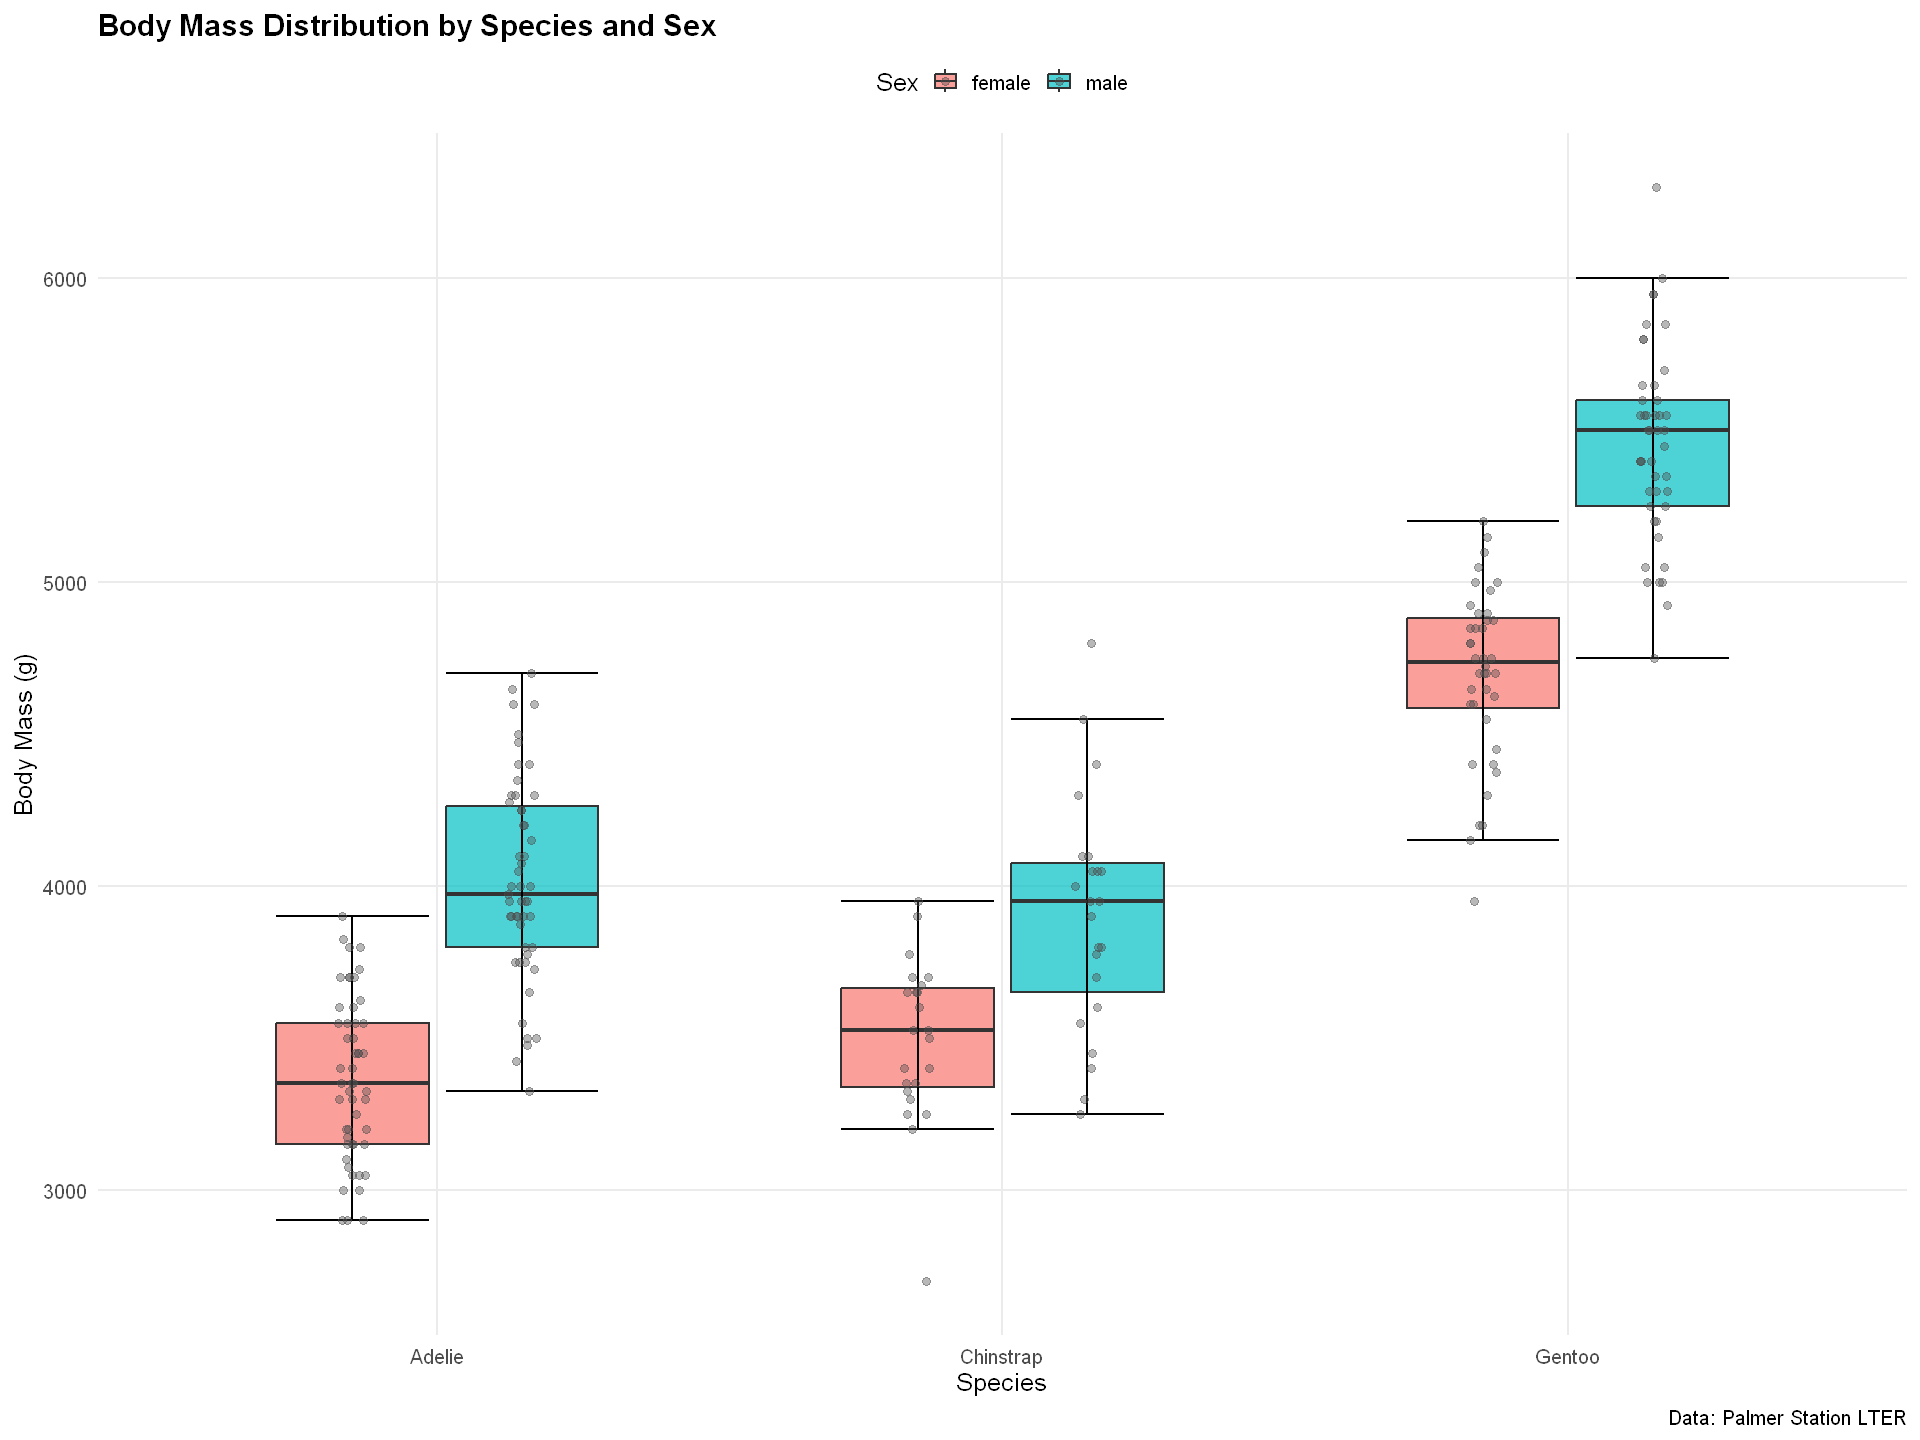

In [199]:
ggplot(df_anova, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA, width = 0.6) +
  stat_boxplot(geom = "errorbar", width = 0.6) + 
  geom_point(position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.6),  # data points with jitter
             alpha = 0.4, size = 2, color = "grey30") +
  theme_minimal(base_size = 15) +
  scale_fill_manual(values = c("female" = "#f8766d", "male" = "#00bfc4")) +
  labs(
    title = "Body Mass Distribution by Species and Sex",
    x = "Species",
    y = "Body Mass (g)",
    fill = "Sex",
    caption = "Data: Palmer Station LTER"
  ) +
  
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold")
  )

In [200]:
linear_model <- lm(body_mass_g ~ species * sex, data = df_anova) # use * to have species, sex and the interaction in the model
summary(linear_model)


Call:
lm(formula = body_mass_g ~ species * sex, data = df_anova)

Residuals:
    Min      1Q  Median      3Q     Max 
-792.39 -205.00    0.63  194.57  894.57 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)               3367.16      43.21  77.927   <2e-16 ***
speciesChinstrap           125.23      77.50   1.616   0.1075    
speciesGentoo             1332.22      65.17  20.441   <2e-16 ***
sexmale                    653.43      61.11  10.693   <2e-16 ***
speciesChinstrap:sexmale  -240.39     109.61  -2.193   0.0293 *  
speciesGentoo:sexmale      102.19      90.72   1.126   0.2612    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 308.6 on 227 degrees of freedom
Multiple R-squared:  0.8587,	Adjusted R-squared:  0.8556 
F-statistic: 275.9 on 5 and 227 DF,  p-value: < 2.2e-16


In [201]:
anova_model <- aov(linear_model)
summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 106425391 53212696 558.848 <2e-16 ***
sex           1  24061363 24061363 252.696 <2e-16 ***
species:sex   2    879505   439752   4.618 0.0108 *  
Residuals   227  21614594    95218                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Based on the results above we can safely reject H0_a and H0_b since the p-value is very small. Thus we can assume that both species and sex have a significant effect on body_mass_g. Also the p-value for the interaction between species and sex is very small, thus one could argue that one of the factors depends on the level of the other factor. For this example this could mean, that the difference between genders differs based on the species of penguins or vice versa which makes sense from a bilogical point (i.e. for some species the "gap" between genders is different than for others).


In [202]:
effect_sizes <- eta_squared(linear_model) |> 
  interpret_eta_squared()

print(effect_sizes)

     species          sex  species:sex 
     "large"      "large" "very small" 
(Rules: field2013)


The function eta_sqared calculates the ratio of variance explained by each factor. When performing the ANOVA in the previos step we found out that the factors have an effect on our dependent variable body_mass_g. Now we are interested in "how much" effect each factor has on the variable. Species and sex have a large influence and therefore mainly responsible for the differences while the interaction of both has a very small influence. This leads to the conclusion that the gap between male and female penguins is equally sized for all species.


In [203]:
# species:sex interaction has small effect size, will thus not be used further
lm_no_interactions <- lm(body_mass_g ~ sex + species, data=df_anova) 
emmeans(lm_no_interactions, ~sex) |> pairs() |> print()
emmeans(lm_no_interactions, ~species) |> pairs()|> print()

 contrast      estimate   SE  df t.ratio p.value
 female - male     -643 41.1 229 -15.651 <0.0001

Results are averaged over the levels of: species 
 contrast           estimate   SE  df t.ratio p.value
 Adelie - Chinstrap    -5.04 55.7 229  -0.091  0.9955
 Adelie - Gentoo    -1386.62 46.0 229 -30.115 <0.0001
 Chinstrap - Gentoo -1381.58 57.4 229 -24.078 <0.0001

Results are averaged over the levels of: sex 
P value adjustment: tukey method for comparing a family of 3 estimates 


Emmeans are calculated for each factor while holding the other factor constant to show how comparable the levels under investigation are, and results can be interpreted as such:

- contrast: groups being compared (e.g. female - male)
- estimate: actual difference between groups (e.g. -650... females are on avg. 650g lighter)
- se: standard error, noisiyness
- p.value: Probability that the difference happened "by chance"

**Interpretation:**
A significant difference in weight was observed between males and females, Adelies and Gentoos as well as Chinstraps and Gentoos. Overal the results quantify what the plots from EDA suggested: Males are heavier than females (by ~640g), Gentoos are the heaviest penguins (by ~1.4 kg) and the difference in weight between Adelies and Chinstraps is so small that it could be purely by chance (i.e. not significant).


### Checking Assumptions


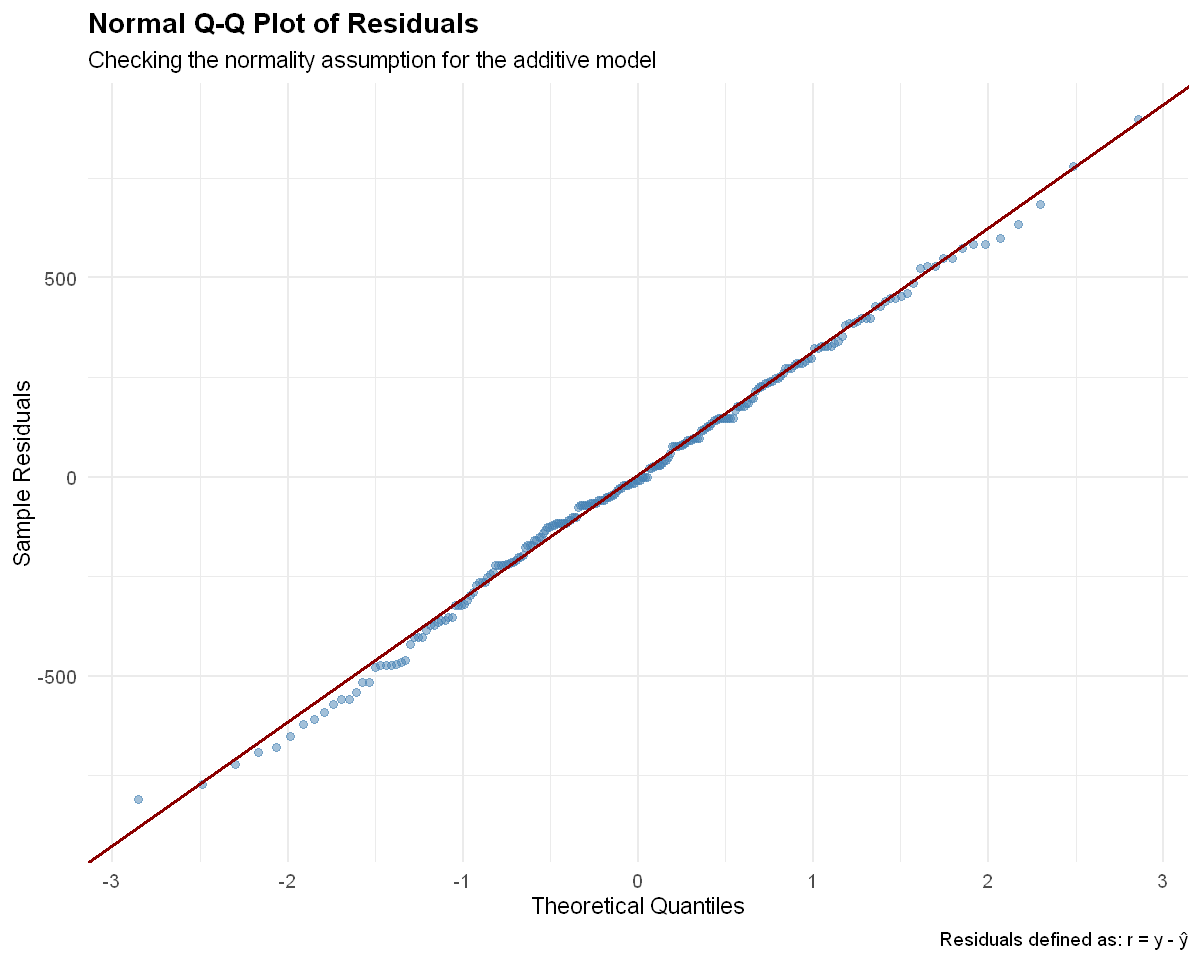

In [204]:
train_set$residuals <- lm_no_interactions$residuals
train_set$fitted <- lm_no_interactions$fitted.values

options(repr.plot.width = 10, repr.plot.height = 8)

train_set |>
  ggplot(aes(sample = residuals)) +
  stat_qq(color = "steelblue", alpha = 0.5, size = 2) +
  # 2. Add a thick, distinct line
  stat_qq_line(color = "darkred", linewidth = 1) +
  # 3. Clean labels and theme
  theme_minimal(base_size = 14) +
  labs(
    title = "Normal Q-Q Plot of Residuals",
    subtitle = "Checking the normality assumption for the additive model",
    x = "Theoretical Quantiles",
    y = "Sample Residuals",
    caption = "Residuals defined as: r = y - ŷ"
  ) +
  theme(plot.title = element_text(face = "bold"))

In [206]:
shapiro.test(train_set$residuals)


	Shapiro-Wilk normality test

data:  train_set$residuals
W = 0.99656, p-value = 0.892


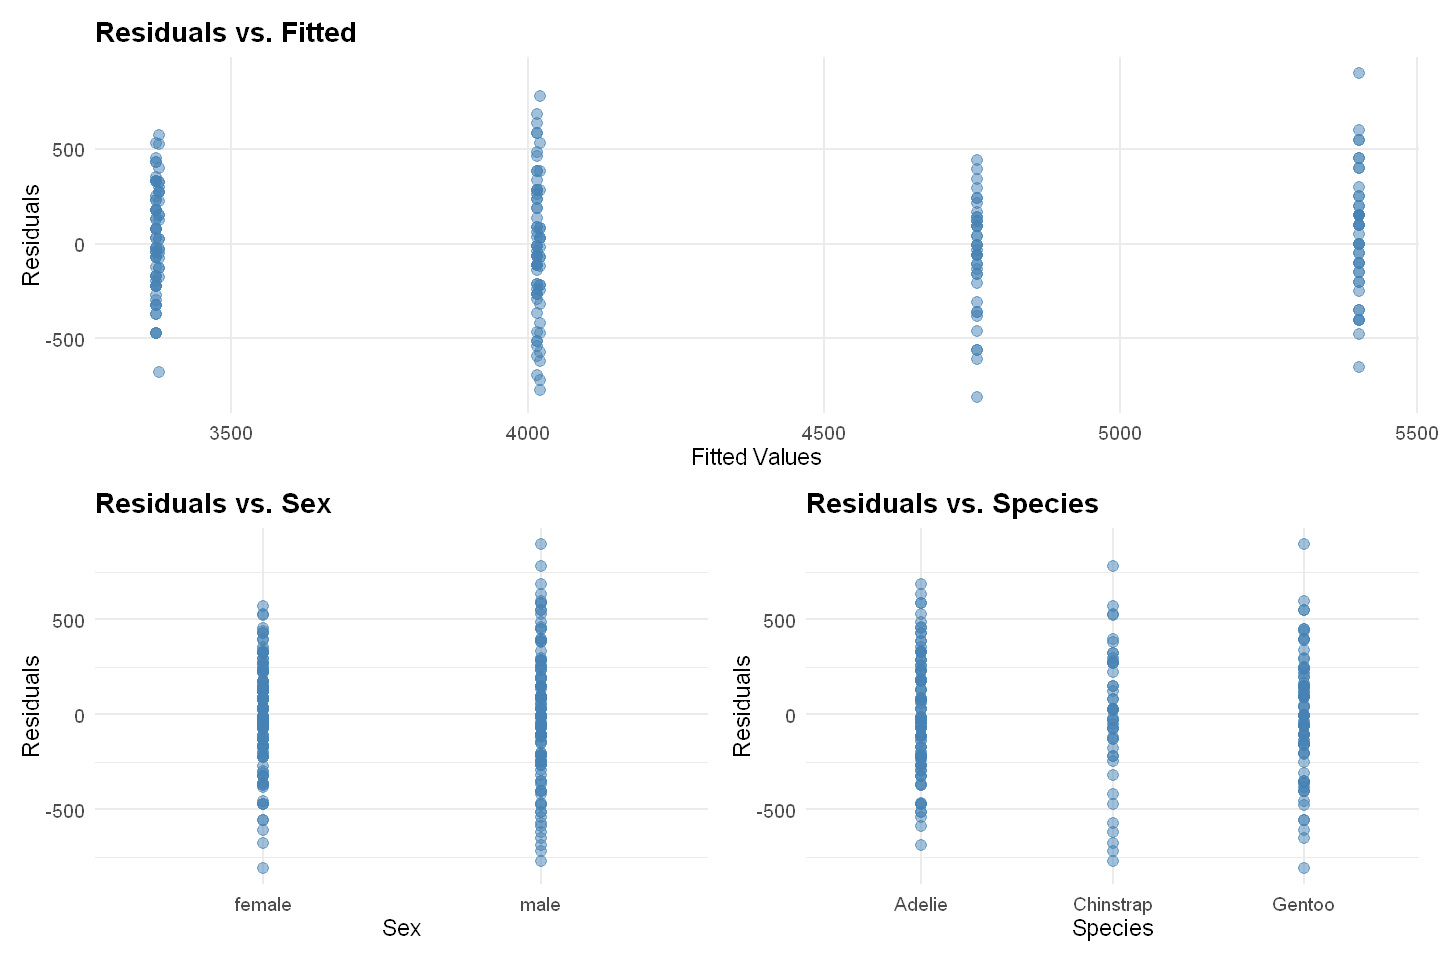

In [229]:
options(repr.plot.width = 12, repr.plot.height = 8)

# fitted vs. residuals
p1 <- ggplot(train_set, aes(x = fitted, y = residuals)) +
  geom_point(size = 3, alpha = 0.5, color = "steelblue") +
  theme_minimal(base_size = 14) +
  labs(title = "Residuals vs. Fitted", x = "Fitted Values", y = "Residuals") +
  theme(plot.title = element_text(face = "bold"), panel.grid.minor = element_blank())

# sex vs. residuals
p2 <- ggplot(train_set, aes(x = sex, y = residuals, fill = sex)) +
  geom_point(size = 3, alpha = 0.5, color = "steelblue") +
  theme_minimal(base_size = 14) +
  labs(title = "Residuals vs. Sex", x = "Sex", y = "Residuals") +
  theme(plot.title = element_text(face = "bold"), legend.position = "none")

# species vs. residuals
p3 <- ggplot(train_set, aes(x = species, y = residuals, fill = species)) +
  geom_point(size = 3, alpha = 0.5, color = "steelblue") +
  theme_minimal(base_size = 14) +
  labs(title = "Residuals vs. Species", x = "Species", y = "Residuals") +
  theme(plot.title = element_text(face = "bold"), legend.position = "none")

# p1 on top, p2 and p3 below
p1 / (p2 + p3)

The plot above compares the residuals to Fitted values, sex and species to show potential homoscedasticity which is not present in the models predictions. We see that the models predictions (fitted values) show 4 separate, vertical bars, which is common when a linear model preforms predictions based on very few categorical feautres which is the case here.


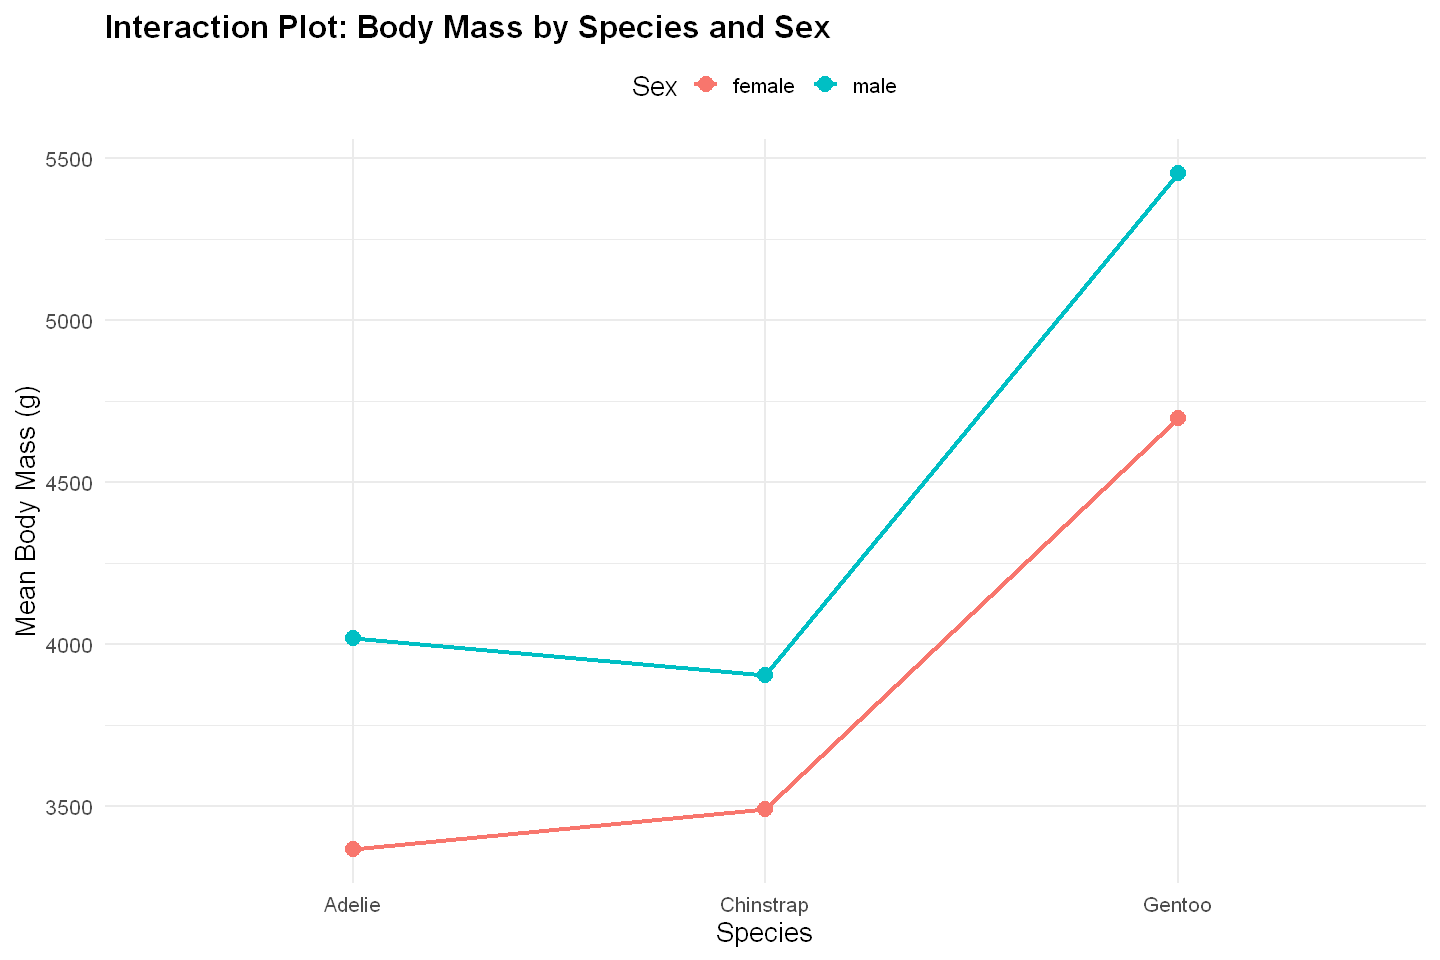

In [230]:
train_set |>
  ggplot(aes(x = species, y = body_mass_g, color = sex, group = sex)) +
  stat_summary(fun = mean, geom = "point", size = 4) + # mean as points
  stat_summary(fun = mean, geom = "line", linewidth = 1.2) + # lines between points
  theme_minimal(base_size = 16) +
  labs(
    title = "Interaction Plot: Body Mass by Species and Sex",
    x = "Species",
    y = "Mean Body Mass (g)",
    color = "Sex"
  ) +
  theme(
    plot.title = element_text(face = "bold"),
    legend.position = "top"
  )

The upward slope of both lines toward the Gentoos indicates that Gentoos tend to be heavier than Adelie and Chinstrap penguins. Since the lines are not perfectly parallel, the plot suggests an interaction where the effect of sex on body mass varies depending on the different species. The widening vertical gap at the Gentoo data point shows that the differences between genders are stronger in that species than in the other two.


In [232]:
leveneTest(residuals ~ sex, data = train_set) |> print()
leveneTest(residuals ~ species, data = train_set) |> print()

Levene's Test for Homogeneity of Variance (center = median)
       Df F value  Pr(>F)  
group   1  3.1992 0.07498 .
      231                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   2  0.4081 0.6654
      230               


The levene test is used to check for homogenity of variances, it states the following hypotheses:
H0: The Variance is equal across all groups
H1: The Variance is not eqaul across all groups

For both factors the test holds f-values > 0.05 which means that there is no significant evidence that the variances are different across genders and species. Since homogenity of variances is another assumption that anova has this is also a good sign.


## Classification: Species


## Regression: Body Mass
